# DEKLARASI LIBRARY & PACKAGES

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, precision_recall_curve

import joblib

#Theme Setup
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# BAGIAN 1: DATA PREPROCESSING & EDA

## Data Loading & Exploration

In [25]:
df = pd.read_csv('data.csv', sep=';')
print(f"Ukuran dataset awal: {df.shape[0]} baris, {df.shape[1]} kolom\n")

Ukuran dataset awal: 4424 baris, 37 kolom



In [26]:
df.columns = df.columns.str.strip()

## Data Cleaning & Filtering Target

In [27]:
df = df[df['Target'] != 'Enrolled']

In [28]:
df['Target'] = df['Target'].map({'Dropout': 1, 'Graduate': 0})

In [29]:
missing_count = df.isnull().sum().sum()
duplicate_count = df.duplicated().sum()
print(f"Jumlah Missing Values ditemukan: {missing_count}")
print(f"Jumlah Baris Duplikat ditemukan: {duplicate_count}")

Jumlah Missing Values ditemukan: 0
Jumlah Baris Duplikat ditemukan: 0


In [30]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print(f"Ukuran dataset setelah dibersihkan: {df.shape[0]} baris\n")

Ukuran dataset setelah dibersihkan: 3630 baris



##Feature Engineering

In [31]:
df['Total_Approved_Units'] = df['Curricular units 1st sem (approved)'] + df['Curricular units 2nd sem (approved)']

In [32]:
df['Grade_Incentive'] = df['Curricular units 2nd sem (grade)'] - df['Curricular units 1st sem (grade)']

In [33]:
print("Fitur baru berhasil dibuat: 'Total_Approved_Units' dan 'Grade_Incentive'.\n")

Fitur baru berhasil dibuat: 'Total_Approved_Units' dan 'Grade_Incentive'.



##Exploratory Data Analysis

###Visualisasi 1: Distribusi Target (Dropout vs Graduate)

/tmp/ipykernel_465/3743812378.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Target', data=df, palette='Set2')


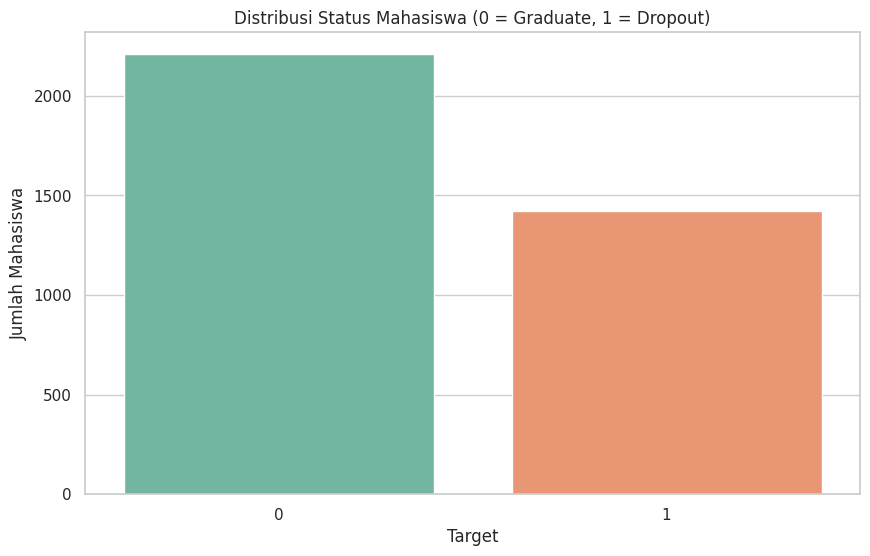

In [34]:
plt.figure()
sns.countplot(x='Target', data=df, palette='Set2')
plt.title('Distribusi Status Mahasiswa (0 = Graduate, 1 = Dropout)')
plt.xlabel('Target')
plt.ylabel('Jumlah Mahasiswa')
plt.show()

###Visualisasi 2: Hubungan antara Total Mata Kuliah Lulus dengan Risiko Dropout

/tmp/ipykernel_465/3458296239.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y='Total_Approved_Units', data=df, palette='Pastel1')


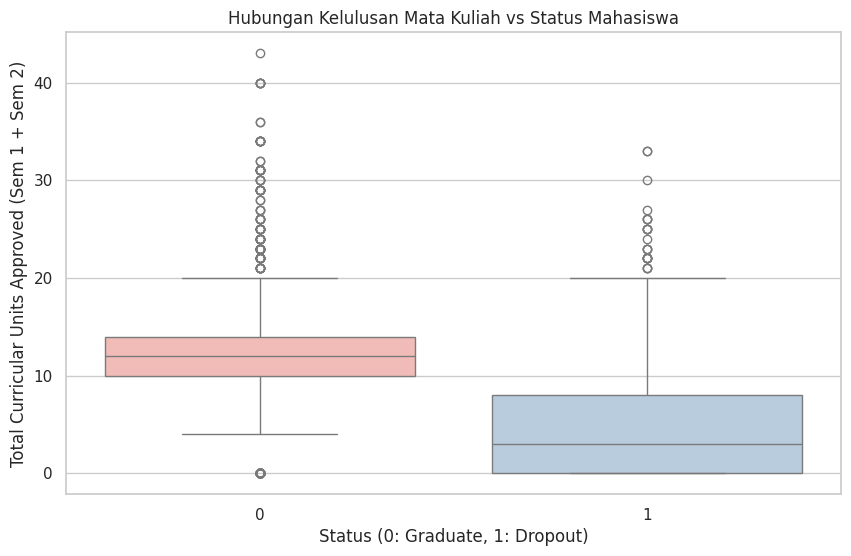

In [35]:
plt.figure()
sns.boxplot(x='Target', y='Total_Approved_Units', data=df, palette='Pastel1')
plt.title('Hubungan Kelulusan Mata Kuliah vs Status Mahasiswa')
plt.xlabel('Status (0: Graduate, 1: Dropout)')
plt.ylabel('Total Curricular Units Approved (Sem 1 + Sem 2)')
plt.show()

##Proper Train-Test Split

In [36]:
X = df.drop('Target', axis=1)
y = df['Target']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Ukuran Data Training : {X_train.shape}")
print(f"Ukuran Data Testing  : {X_test.shape}\n")

Ukuran Data Training : (2904, 38)
Ukuran Data Testing  : (726, 38)



##Scaling & Normalization

In [38]:
numerical_features = ['Age at enrollment', 'Admission grade', 'Previous qualification (grade)',
                      'Total_Approved_Units', 'Grade_Incentive', 'Curricular units 1st sem (grade)',
                      'Curricular units 2nd sem (grade)']

scaler = StandardScaler()

In [39]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])
print("StandardScaler berhasil diterapkan pada fitur-fitur numerik kunci.\n")

StandardScaler berhasil diterapkan pada fitur-fitur numerik kunci.



# BAGIAN 2: MODEL IMPLEMENTATION & HYPERPARAMETER TUNING

In [40]:
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train_scaled, y_train)
print("Model Random Forest Classifier berhasil dilatih dengan pipeline yang proper.\n")

Model Random Forest Classifier berhasil dilatih dengan pipeline yang proper.



# BAGIAN 3: MODEL EVALUATION & PERFORMANCE ANALYSIS

In [41]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [42]:
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Akurasi Akhir Model : {acc:.4f}")
print(f"Skor ROC-AUC        : {roc_auc:.4f}\n")
print("Laporan Klasifikasi Lengkap (Classification Report):")
print(classification_report(y_test, y_pred, target_names=['Graduate', 'Dropout']))

Akurasi Akhir Model : 0.9229
Skor ROC-AUC        : 0.9719

Laporan Klasifikasi Lengkap (Classification Report):
              precision    recall  f1-score   support

    Graduate       0.92      0.95      0.94       442
     Dropout       0.93      0.87      0.90       284

    accuracy                           0.92       726
   macro avg       0.92      0.91      0.92       726
weighted avg       0.92      0.92      0.92       726



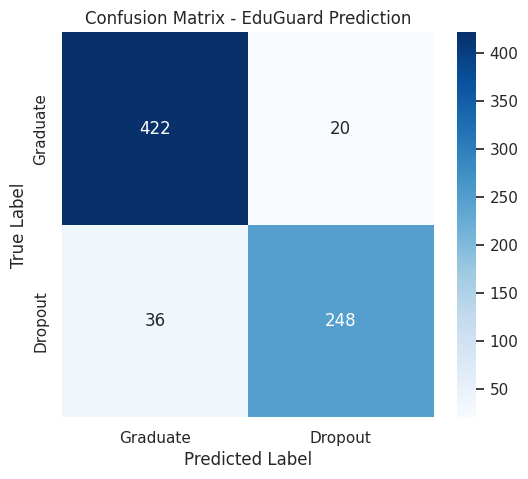

In [43]:
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Graduate', 'Dropout'], yticklabels=['Graduate', 'Dropout'])
plt.title('Confusion Matrix - EduGuard Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

/tmp/ipykernel_465/1439223933.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_imp.head(7).values, y=feature_imp.head(7).index, palette='viridis')


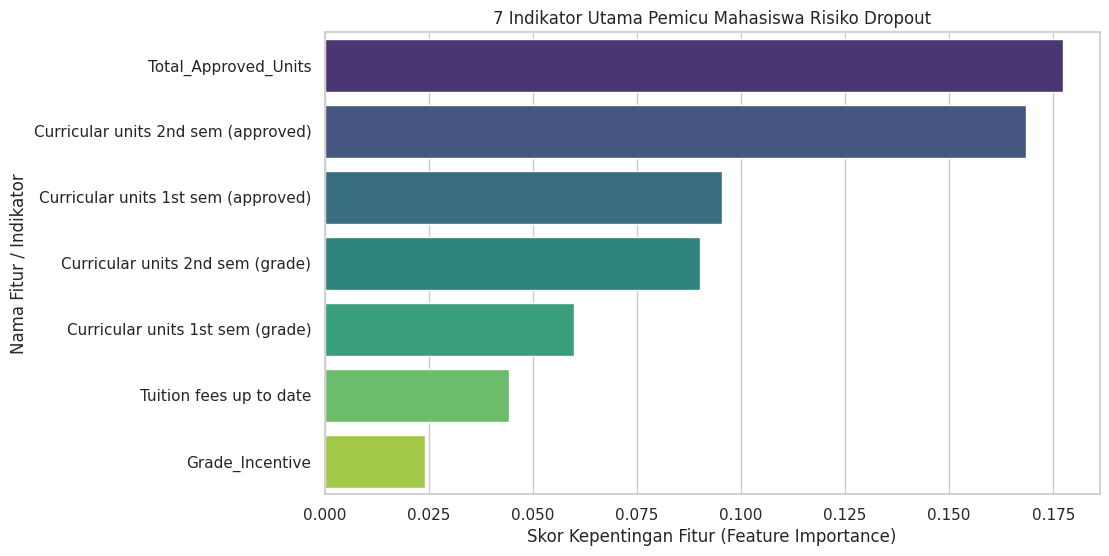


7 Fitur Teratas yang Paling Berpengaruh:
Total_Approved_Units                   0.177237
Curricular units 2nd sem (approved)    0.168569
Curricular units 1st sem (approved)    0.095569
Curricular units 2nd sem (grade)       0.090181
Curricular units 1st sem (grade)       0.059908
Tuition fees up to date                0.044384
Grade_Incentive                        0.024231
dtype: float64


In [44]:
importances = model.feature_importances_
feature_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure()
sns.barplot(x=feature_imp.head(7).values, y=feature_imp.head(7).index, palette='viridis')
plt.title('7 Indikator Utama Pemicu Mahasiswa Risiko Dropout')
plt.xlabel('Skor Kepentingan Fitur (Feature Importance)')
plt.ylabel('Nama Fitur / Indikator')
plt.show()

print("\n7 Fitur Teratas yang Paling Berpengaruh:")
print(feature_imp.head(7))

# BAGIAN 4: EXPORT MODEL & UTILITAS UNTUK STREAMLIT

In [45]:
joblib.dump(model, 'model_dropout.pkl')
joblib.dump(scaler, 'scaler_dropout.pkl')

['scaler_dropout.pkl']

In [46]:
joblib.dump(feature_imp.head(7).index.tolist(), 'selected_features.pkl')
print("Semua file pkl ('model_dropout.pkl', 'scaler_dropout.pkl', 'selected_features.pkl') sukses diexport!")

Semua file pkl ('model_dropout.pkl', 'scaler_dropout.pkl', 'selected_features.pkl') sukses diexport!
